# Example: Streaming Regression with RLS & Kalman Filter

Demonstrates infinite-scale streaming updates with constant $\mathcal{O}(D^2)$ memory and real-time parameter tracking.

RLS Recovered Parameters: w=[ 3.0028 -1.9983], b=1.0004
Samples Processed: 1000


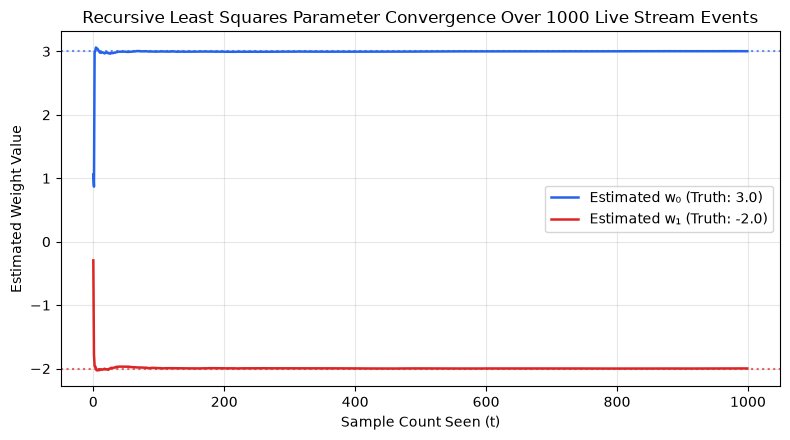

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.streaming import RecursiveLeastSquares, KalmanFilterRegression

np.random.seed(42)
N = 1000
X = np.random.randn(N, 2)
y = 3.0 * X[:, 0] - 2.0 * X[:, 1] + 1.0 + np.random.normal(0, 0.1, N)

rls = RecursiveLeastSquares(lambda_=1.0)
w0_history, w1_history = [], []
for i in range(N):
    rls.partial_fit(X[i], y[i])
    w0_history.append(rls.weights[0])
    w1_history.append(rls.weights[1])

print(f"RLS Recovered Parameters: w={np.round(rls.weights, 4)}, b={rls.bias:.4f}")
print(f"Samples Processed: {rls.n_samples_seen_}")

plt.figure(figsize=(8, 4.5))
plt.plot(w0_history, label='Estimated w₀ (Truth: 3.0)', color='#2563eb', lw=1.8)
plt.axhline(3.0, color='#2563eb', linestyle=':', alpha=0.7)
plt.plot(w1_history, label='Estimated w₁ (Truth: -2.0)', color='#dc2626', lw=1.8)
plt.axhline(-2.0, color='#dc2626', linestyle=':', alpha=0.7)
plt.title(f"Recursive Least Squares Parameter Convergence Over {N} Live Stream Events")
plt.xlabel("Sample Count Seen (t)")
plt.ylabel("Estimated Weight Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What You Learned
- Processing live data point-by-point without storing past observations.
- Observing exponential parameter convergence with Sherman-Morrison rank-1 updates.